## C3DIR Outputs:

3D Voxel: lat x lon x alt

Cloud Properties:

| C3DIR output | What it represents | Units |
|---|---|---|
| **Hydrometeor occurrence** | Probability/presence of any cloud/precipitating hydrometeor | **Unitless probability / binary mask** |
| **Ice occurrence** | Presence/probability of ice cloud | **Unitless probability / binary mask** |
| **Liquid occurrence** | Presence/probability of liquid cloud | **Unitless probability / binary mask** |
| **Rain occurrence** | Presence/probability of rain | **Unitless probability / binary mask** |
| **IWC – Ice Water Content** | Mass of ice per volume of air | **g m⁻³** |
| **LWC – Liquid Water Content** | Mass of cloud liquid water per volume of air | **g m⁻³** |
| **RWC – Rain Water Content** | Mass of rain water per volume of air | **g m⁻³** |
| **Effective radius** | How large the particles are | **µm** |

## ERA5 Outputs:

https://cds.climate.copernicus.eu/requests?tab=all

3D : lat x lon x pressure level (hPa)

| ERA5 output | Variable | What it represents | Units | Closest C3DIR feature |
|---|---|---|---|---|
| **Divergence** | `d` | Horizontal spreading or convergence of the wind field | **s⁻¹** | — |
| **Fraction of cloud cover** | `cc` | Fraction of the atmospheric grid box covered by cloud | **0–1, unitless** | **Hydrometeor occurrence** *(rough proxy only; not equivalent)* |
| **Geopotential** | `z` | Gravitational potential energy per unit mass; can be converted to geopotential height | **m² s⁻²** | **3D altitude coordinate** *(used to convert pressure levels toward altitude)* |
| **Ozone mass mixing ratio** | `o3` | Mass of ozone per unit mass of moist air | **kg kg⁻¹** | — |
| **Potential vorticity** | `pv` | Atmospheric rotation combined with vertical stability | **K m² kg⁻¹ s⁻¹** | — |
| **Relative humidity** | `r` | Water vapor relative to saturation at the given temperature | **%** | — |
| **Specific cloud ice water content** | `ciwc` | Mass of cloud ice per unit mass of moist air | **kg kg⁻¹** | **Ice occurrence**, **IWC** |
| **Specific cloud liquid water content** | `clwc` | Mass of cloud liquid water per unit mass of moist air | **kg kg⁻¹** | **Liquid occurrence**, **LWC** |
| **Specific humidity** | `q` | Mass of water vapor per unit mass of moist air | **kg kg⁻¹** | — *(used in air-density conversion)* |
| **Specific rain water content** | `crwc` | Mass of rain water per unit mass of moist air | **kg kg⁻¹** | **Rain occurrence**, **RWC** |
| **Specific snow water content** | `cswc` | Mass of snow/frozen precipitation per unit mass of moist air | **kg kg⁻¹** | **Hydrometeor occurrence** |
| **Temperature** | `t` | Atmospheric air temperature | **K** | — *(used in air-density conversion)* |
| **U-component of wind** | `u` | East-west component of wind velocity | **m s⁻¹** | — |
| **V-component of wind** | `v` | North-south component of wind velocity | **m s⁻¹** | — |
| **Vertical velocity** | `w` | Vertical atmospheric motion expressed as pressure change | **Pa s⁻¹** | — |
| **Vorticity (relative)** | `vo` | Local rotation of the horizontal wind field | **s⁻¹** | — |

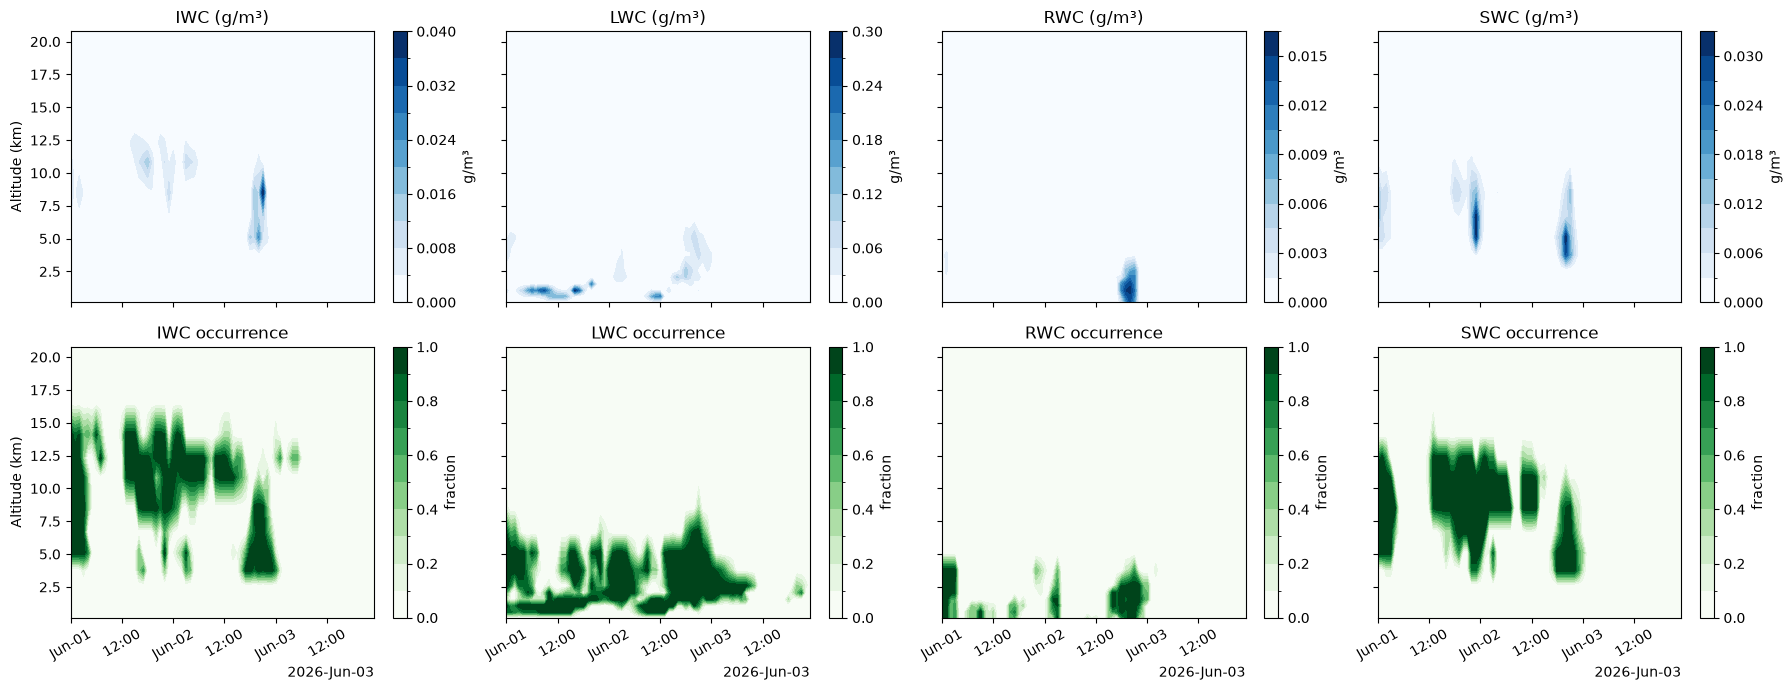

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("../data/era5/atl_subset/era5_20260601_20260603.nc")

# 3D altitude coordinate (km) from geopotential; air density (kg/m³) from p, T, q
alt_km = (ds.z / 9.80665 / 1000).mean(["valid_time", "latitude", "longitude"])
rho = ds.pressure_level * 100 / (287.05 * ds.t * (1 + 0.61 * ds.q))

# kg/kg -> g/m³ for each hydrometeor (domain-mean content, plus occurrence = fraction of grid points > 1e-4 g/m³)
names = {"IWC": "ciwc", "LWC": "clwc", "RWC": "crwc", "SWC": "cswc"}
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True, sharey=True)
for i, (name, v) in enumerate(names.items()):
    c = (ds[v] * rho * 1000).assign_coords(alt_km=alt_km)
    kw = dict(x="valid_time", y="alt_km")
    c.mean(["latitude", "longitude"]).plot.contourf(**kw, ax=axes[0, i], cmap="Blues", levels=12,
                                                    cbar_kwargs={"label": "g/m³"})
    (c > 1e-4).mean(["latitude", "longitude"]).plot.contourf(**kw, ax=axes[1, i], cmap="Greens",
                                                             levels=np.linspace(0, 1, 11), cbar_kwargs={"label": "fraction"})
    axes[0, i].set_title(f"{name} (g/m³)")
    axes[1, i].set_title(f"{name} occurrence")
for ax in axes.flat:
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
for ax in axes[:, 0]:
    ax.set_ylabel("Altitude (km)")
plt.tight_layout()
plt.show()